In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluacija modela klasterovanja

Nakon sprovedene pripreme podataka, smanjenja dimenzionalnosti primenom PCA metode i treniranja vise algoritama klasterovanja, naredni korak predstavlja evaluaciju dobijenih modela.

U ovom notebook-u analiziraju se rezultati pet primenjenih algoritama:

- K-Means
- Gaussian Mixture Model (GMM) (sa 4 i 9 dobijenih klastera)
- BIRCH
- Agglomerative Clustering
- Spectral Clustering

Evaluacija se ne zasniva iskljucivo na internim metrikama kvaliteta klasterovanja, vec i na interpretabilnosti dobijenih segmenata. Pored poredjenja silhouette score vrednosti i raspodele instanci po klasterima, analiziraju se i karakteristike oglasa koje nisu koriscene tokom klasterovanja, poput plata, nivoa iskustva, velicine kompanije, industrije i trazenih vestina.

Cilj ove analize je identifikacija modela koji ne samo da ostvaruje dobre numericke rezultate, vec i formira klastere koji imaju poslovno smisleno tumacenje i omogucavaju bolje razumevanje strukture trzista rada predstavljenog u LinkedIn Job Postings skupu podataka.

In [2]:
kmeans_labels = pd.read_csv(
    "../models/kmeans_labels.csv"
).squeeze("columns")

gmm_labels = pd.read_csv(
    "../models/gmm_labels.csv"
).squeeze("columns")

gmm_9_labels = pd.read_csv(
    "../models/gmm_9_labels.csv"
).squeeze("columns")

birch_labels = pd.read_csv(
    "../models/birch_labels.csv"
).squeeze("columns")

agg_labels = pd.read_csv(
    "../models/agg_labels.csv"
).squeeze("columns")

spectral_labels = pd.read_csv(
    "../models/spectral_labels.csv"
).squeeze("columns")
kmeans_no_label = pd.read_csv(
    "../models/kmeans_no_title_labels.csv"
).squeeze("columns")

## Napomena o obimu podataka koriscenom tokom evaluacije

K-Means, GMM i BIRCH algoritmi evaluirani su nad kompletnim skupom podataka koji sadrzi 123.849 oglasa za posao. Time je omogucena direktna analiza klastera na nivou celokupnog skupa podataka.

Sa druge strane, zbog znacajne racunske slozenosti algoritama Agglomerative Clustering i Spectral Clustering, njihova primena nad kompletnim skupom nije bila izvodljiva u raspolozivom okruzenju. Iz tog razloga, Agglomerative Clustering je treniran nad slucajnim uzorkom od 10.000 instanci, dok je Spectral Clustering treniran nad slucajnim uzorkom od 5.000 instanci.

Zbog razlicitog broja instanci koriscenih tokom treniranja i evaluacije, rezultati ova dva algoritma nisu u potpunosti uporedivi sa rezultatima modela treniranih nad celokupnim skupom podataka. Stoga ce K-Means, GMM i BIRCH biti analizirani zajedno, dok ce Agglomerative i Spectral Clustering biti razmatrani odvojeno, uzimajuci u obzir ogranicenja vezana za velicinu uzorka.

In [3]:
models_info = pd.DataFrame({
    "model": [
        "KMeans",
        "GMM k=4",
        "GMM k=9",
        "BIRCH",
        "Agglomerative",
        "Spectral"
    ],
    "n_labels": [
        len(kmeans_labels),
        len(gmm_labels),
        len(gmm_9_labels),
        len(birch_labels),
        len(agg_labels),
        len(spectral_labels)
    ]
})

models_info

,model,n_labels
0,KMeans,123849
1,GMM k=4,123849
2,GMM k=9,123849
3,BIRCH,123849
4,Agglomerative,10000
5,Spectral,5000


## Raspodela instanci po klasterima

Pored vrednosti silhouette score metrike, znacajan aspekt evaluacije predstavlja i analiza raspodele instanci po formiranim klasterima. Pozeljno je da klasteri budu relativno uravnotezeni, odnosno da ne postoji veliki broj veoma malih ili veoma velikih klastera, jer takva raspodela moze ukazivati na preteranu fragmentaciju podataka ili na nedovoljno izdvajanje razlicitih grupa.

Na narednom grafikonu prikazan je procenat instanci koji pripada svakom klasteru za sve analizirane modele. Na osnovu ovih rezultata moguce je proceniti da li algoritmi formiraju uravnotezene segmente ili vecinu podataka grupisu u mali broj dominantnih klastera.

Dobijene raspodele predstavljaju dodatni kriterijum za poredjenje modela, jer dobro klasterovanje ne treba da se ogleda samo kroz visoke vrednosti internih metrika, vec i kroz formiranje smislenih i dovoljno zastupljenih grupa unutar skupa podataka.

Vec prilikom klasterovanja, obracana je paznja na distribucije dobijenih klastera i cesto su bili odbacivani modeli sa visokim silhouette score, ali veoma losom raspodelom podataka po klasterima.

In [4]:
def cluster_distribution(labels, model_name):
    dist = (
        pd.Series(labels)
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .reset_index()
    )
    
    dist.columns = ["cluster", "percentage"]
    dist["model"] = model_name
    
    return dist
dist_all = pd.concat([
    cluster_distribution(kmeans_labels, "KMeans"),
    cluster_distribution(gmm_labels, "GMM k=4"),
    cluster_distribution(gmm_9_labels, "GMM k=9"),
    cluster_distribution(birch_labels, "BIRCH"),
    cluster_distribution(agg_labels, "Agglomerative"),
    cluster_distribution(spectral_labels, "Spectral")
], ignore_index=True)

dist_all

,cluster,percentage,model
0,0,42.228036,KMeans
1,1,26.600941,KMeans
2,2,13.031999,KMeans
3,3,18.139024,KMeans
4,0,23.877464,GMM k=4
5,1,21.726457,GMM k=4
6,2,31.301020,GMM k=4
7,3,23.095059,GMM k=4
8,0,15.064312,GMM k=9
9,1,11.554393,GMM k=9


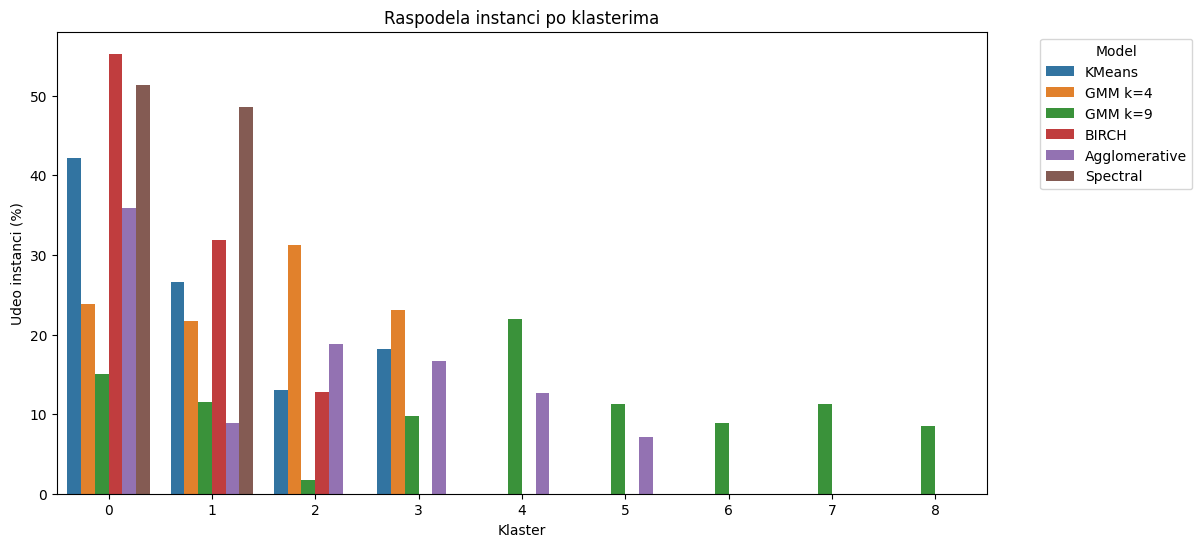

In [5]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=dist_all,
    x="cluster",
    y="percentage",
    hue="model"
)

plt.title("Raspodela instanci po klasterima")
plt.xlabel("Klaster")
plt.ylabel("Udeo instanci (%)")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

Kao sto mozemo videti vecinski su najbolji modeli iz svake tehnike klasterovanja pravili manji broj klastera. Radi analize ostavljeno je dva modela dobijena GMM algoritmom jedan sa 4, a drugi sa 9 klastera. Oni imaju slicne interne ocene, ali je jedna od ideja ove evaluacije procena da li ima vise smisla ove podatke deliti u manje ili vise grupa.

In [6]:
internal_eval = pd.DataFrame({
    "model": [
        "KMeans",
        "GMM k=4",
        "GMM k=9",
        "BIRCH",
        "Agglomerative",
        "Spectral"
    ],
    "pca_components": [
        3, 3, 3, 3, 3, 3
    ],
    "k": [
        4, 4, 9, 3, 6, 2
    ],
    "silhouette_score": [
        0.336,
        0.245,
        0.254,
        0.298,
        0.266,
        0.315
    ],
    "evaluated_on": [
        "full dataset",
        "full dataset",
        "full dataset",
        "full dataset",
        "sample 10000",
        "sample 5000"
    ]
})

internal_eval

,model,pca_components,k,silhouette_score,evaluated_on
0,KMeans,3,4,0.336,full dataset
1,GMM k=4,3,4,0.245,full dataset
2,GMM k=9,3,9,0.254,full dataset
3,BIRCH,3,3,0.298,full dataset
4,Agglomerative,3,6,0.266,sample 10000
5,Spectral,3,2,0.315,sample 5000


Tabela iznad prikazuje najbolje konfiguracije svih analiziranih algoritama klasterovanja, zajedno sa odgovarajucim vrednostima silhouette score metrike.

Najvecu vrednost silhouette score ostvario je K-Means model (0.336), dok su vrlo dobre rezultate ostvarili i Spectral Clustering (0.315) i BIRCH (0.298). GMM modeli i Agglomerative Clustering ostvarili su nesto nize vrednosti, ali su i dalje pokazali prisustvo odredjene klasterske strukture u podacima.

Moze se primetiti da se vrednosti silhouette score za vecinu modela nalaze u intervalu od priblizno 0.25 do 0.34, sto ukazuje na umereno izrazenu strukturu klastera. S obzirom na kompleksnost i heterogenost trzista rada predstavljenog u skupu podataka, ovakve vrednosti mogu se smatrati zadovoljavajucim i dovoljnim za dalju analizu i interpretaciju dobijenih segmenata.

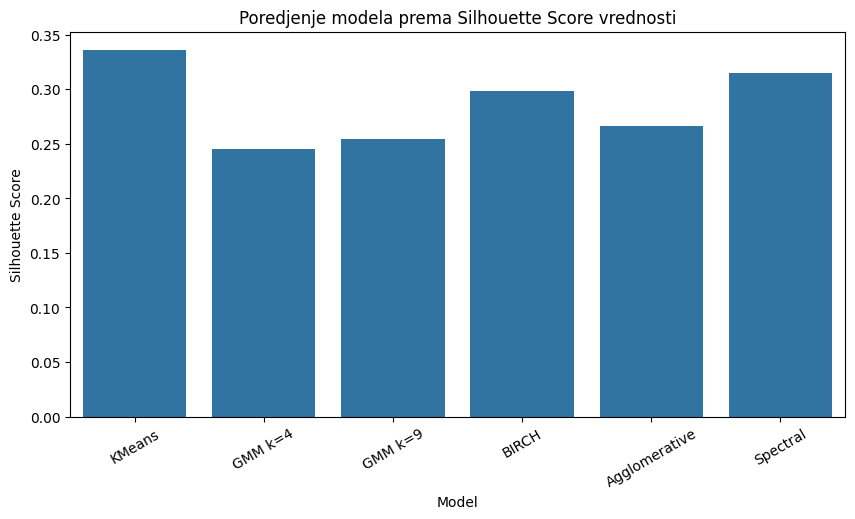

In [58]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=internal_eval,
    x="model",
    y="silhouette_score"
)

plt.title("Poredjenje modela prema Silhouette Score vrednosti")
plt.xlabel("Model")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=30)
plt.show()

Silhouette Score se koristi kao interna mera kvaliteta klasterovanja. Vise vrednosti ukazuju na kompaktnije i bolje razdvojene klastere. Ipak, kod realnih podataka visoke dimenzionalnosti, posebno nakon enkodovanja kategorickih i tekstualnih atributa, umerene vrednosti Silhouette Score-a su ocekivane. Zato se modeli ne ocenjuju iskljucivo na osnovu ove mere, vec se dodatno analiziraju struktura i interpretabilnost dobijenih klastera.

In [8]:
master = pd.read_csv("../data/master_clean.csv")

In [9]:
master.select_dtypes(include="object").columns.tolist()

['title',
 'formatted_work_type',
 'application_type',
 'formatted_experience_level',
 'country']

In [10]:
def set_cluster(labels):
    master["cluster"] = np.asarray(labels, dtype="int16")

In [11]:
model_labels = {
    "KMeans": kmeans_labels,
    "GMM k=4": gmm_labels,
    "GMM k=9": gmm_9_labels,
    "BIRCH": birch_labels
}

analysis_df = master.copy()

for model_name, labels in model_labels.items():
    analysis_df[f"cluster_{model_name}"] = labels

In [12]:
def categorical_profile_all_models(column):
    profiles = []

    for model_name in model_labels.keys():
        cluster_col = f"cluster_{model_name}"

        profile = (
            pd.crosstab(
                analysis_df[cluster_col],
                analysis_df[column],
                normalize="index"
            )
            .mul(100)
            .round(2)
        )

        profile["model"] = model_name
        profile["cluster"] = profile.index
        profiles.append(profile.reset_index(drop=True))

    return pd.concat(profiles, ignore_index=True)

In [16]:
def plot_categorical_profile_all_models(column):

    fig, axes = plt.subplots(
        2, 2,
        figsize=(14, 8)
    )

    axes = axes.flatten()

    for ax, model_name in zip(axes, model_labels.keys()):

        cluster_col = f"cluster_{model_name}"

        profile = (
            pd.crosstab(
                analysis_df[cluster_col],
                analysis_df[column],
                normalize="index"
            )
            .mul(100)
            .round(2)
        )

        profile.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            legend=False
        )

        ax.set_title(model_name)
        ax.set_xlabel("Klaster")
        ax.set_ylabel("%")
        ax.tick_params(axis="x", rotation=0)

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        title=column,
        bbox_to_anchor=(1.02, 0.5),
        loc="center left"
    )

    plt.suptitle(f"{column} po klasterima", fontsize=14)

    plt.tight_layout()
    plt.show()

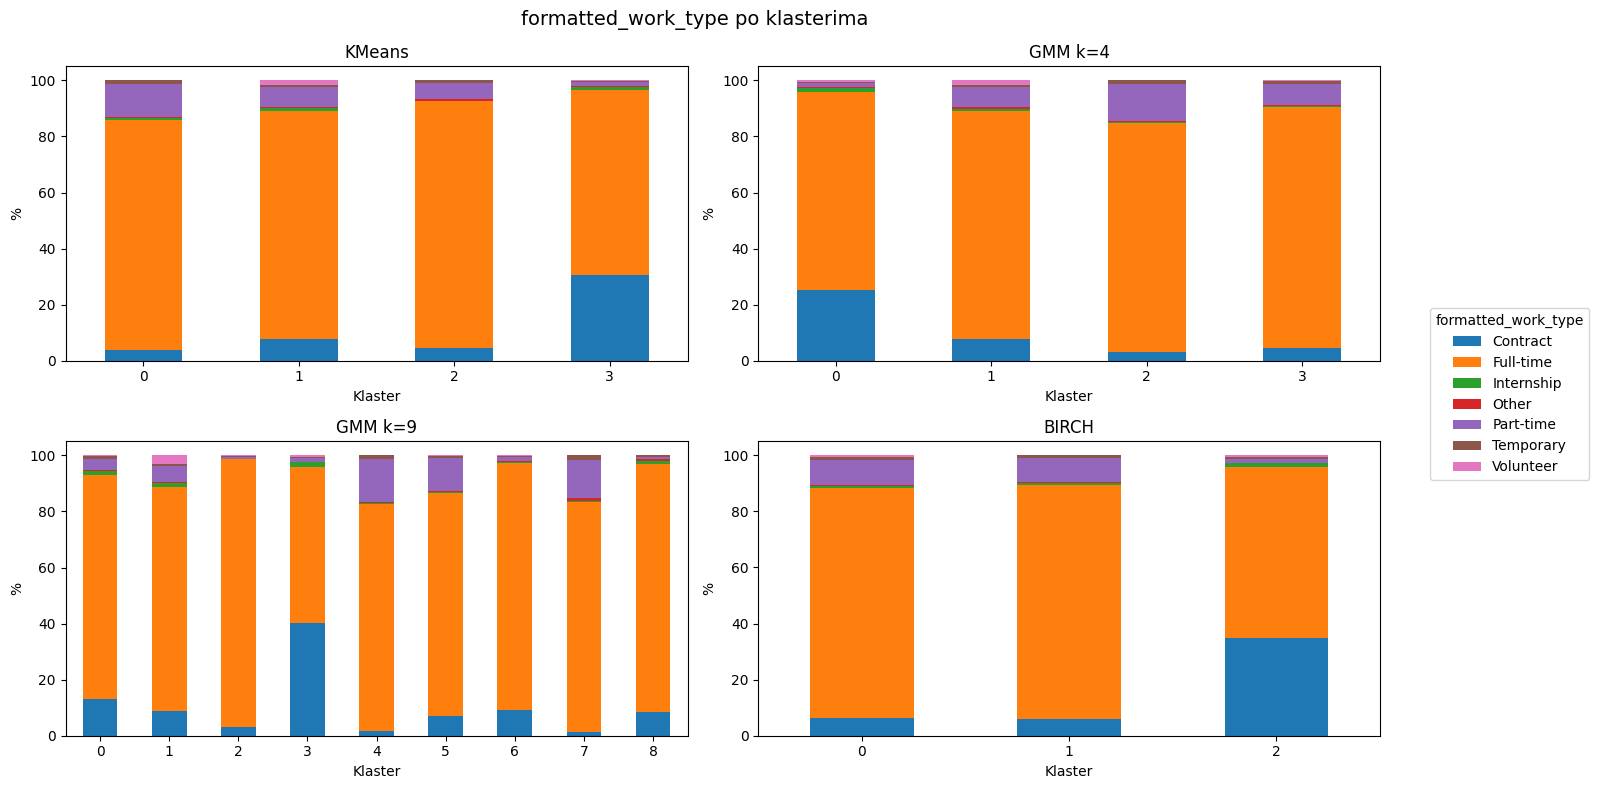

In [17]:
plot_categorical_profile_all_models("formatted_work_type")

Moze se primetiti da u svim modelima dominiraju Full-time pozicije, sto je ocekivano s obzirom na strukturu skupa podataka. Ipak, pojedini klasteri pokazuju povecan udeo Contract poslova, sto ukazuje da tip zaposlenja predstavlja jednu od karakteristika koje doprinose formiranju klastera. Ostale kategorije, poput Part-time i Temporary poslova, pojavljuju se u znatno manjem obimu i nemaju znacajan uticaj na ukupnu strukturu klastera.

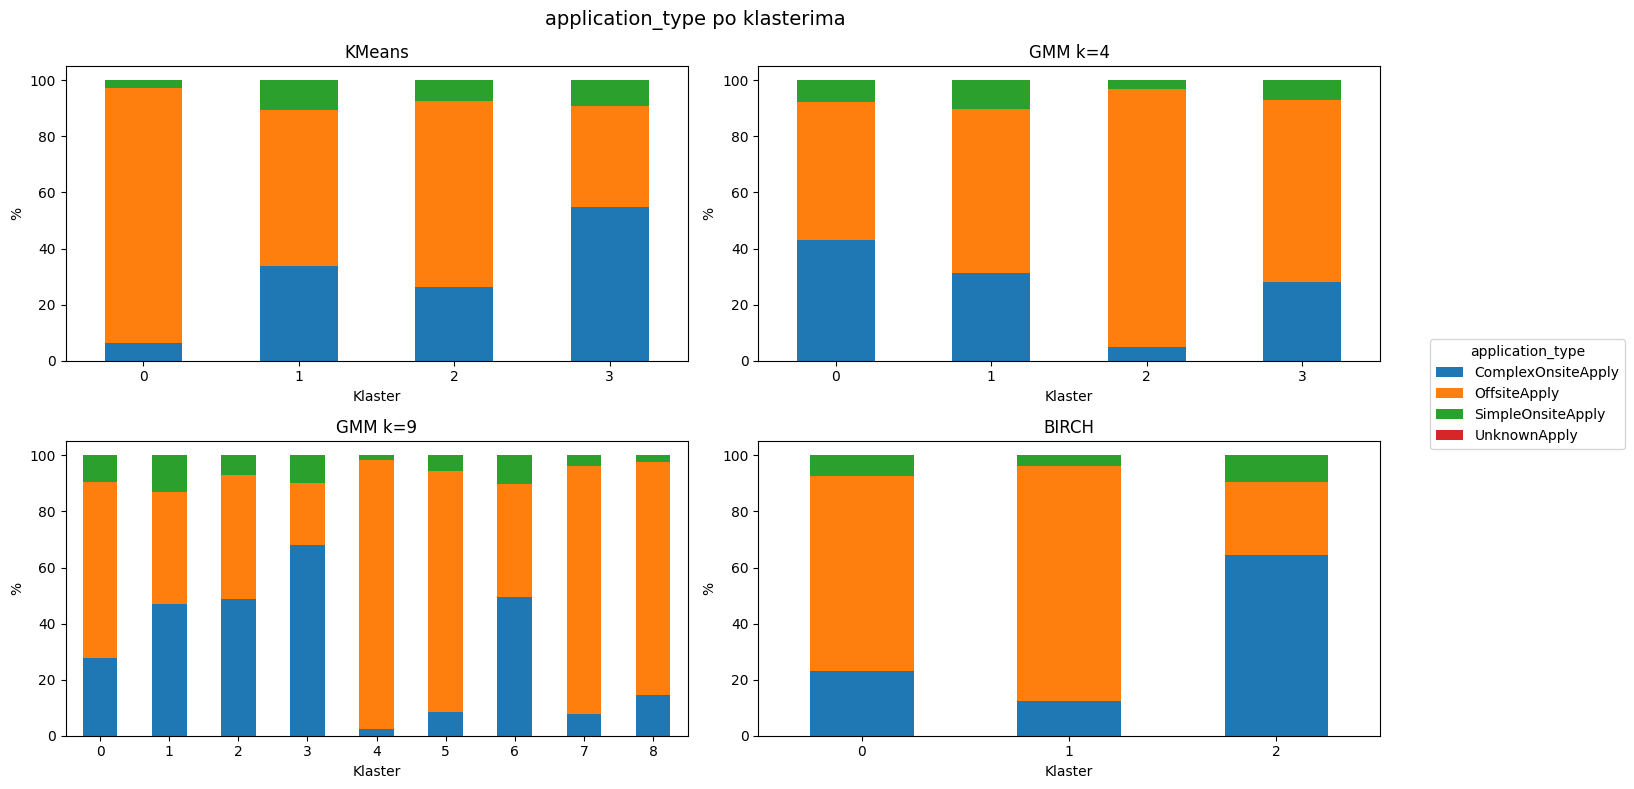

In [18]:
plot_categorical_profile_all_models("application_type")

Analiza tipa prijave pokazuje odredjene razlike izmedju klastera, ali nijedna kategorija ne dominira dovoljno izrazito da bi predstavljala kljucni faktor razlikovanja segmenata. Zbog toga se application_type moze posmatrati kao pomocna karakteristika sa ogranicenim doprinosom interpretaciji klastera.

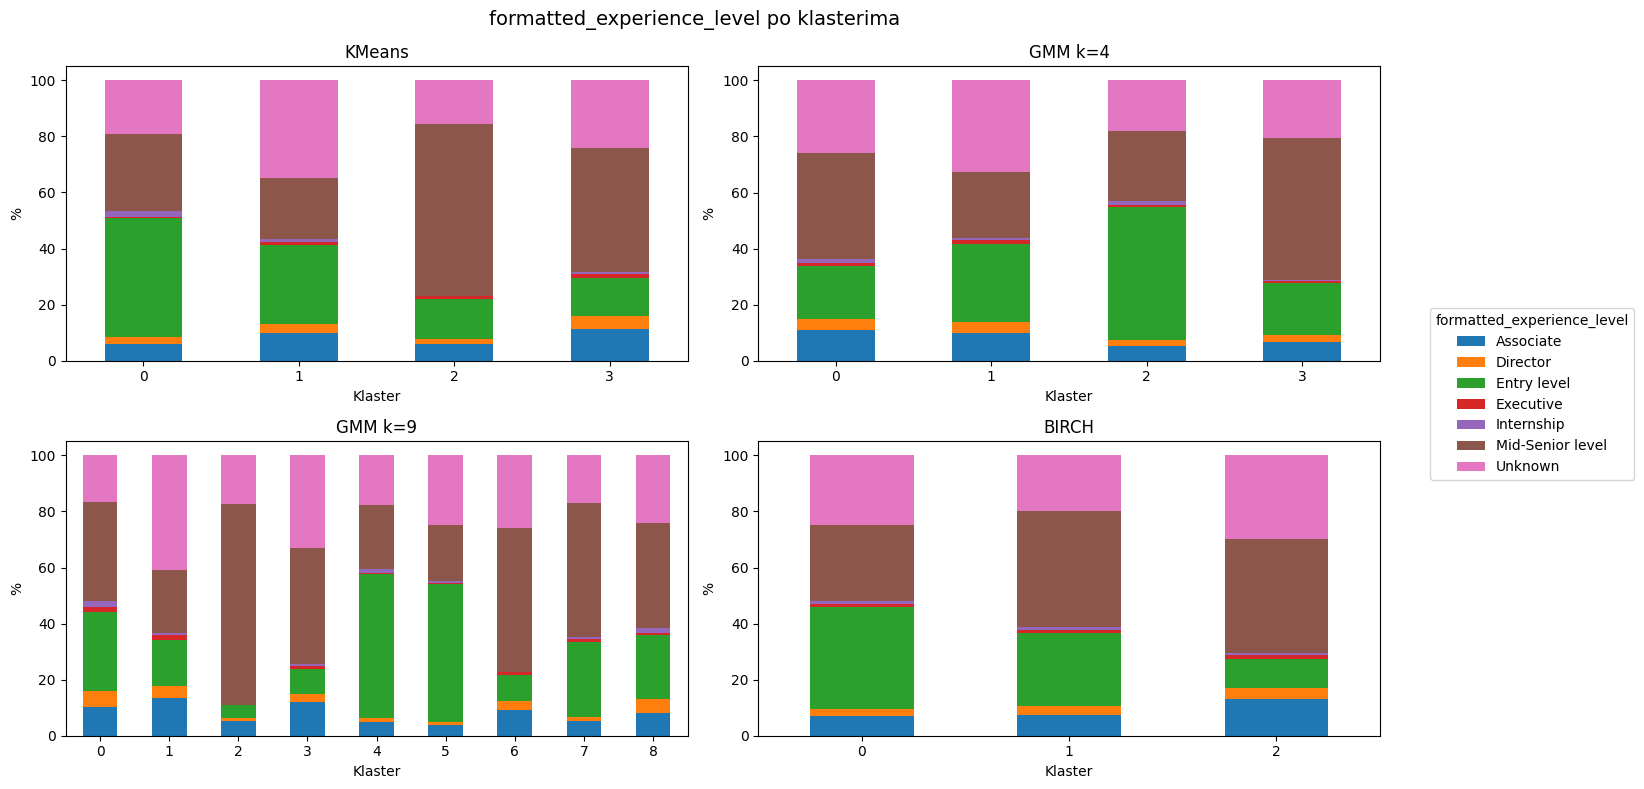

In [19]:
plot_categorical_profile_all_models("formatted_experience_level")

Nivo iskustva pokazuje znatno izrazenije razlike izmedju klastera u odnosu na prethodno analizirane kategorije. U svim modelima mogu se uociti klasteri sa povecanim udelom Executive, Mid-Senior ili Entry level pozicija, sto ukazuje da iskustvo predstavlja jednu od znacajnih karakteristika prilikom segmentacije oglasa za posao.

Posebno su zanimljivi modeli K-Means i GMM, kod kojih pojedini klasteri okupljaju pretezno iskusnije kandidate, dok drugi sadrze veci udeo pocetnickih i srednjih nivoa iskustva. Ovakva raspodela doprinosi boljoj interpretaciji dobijenih segmenata i ukazuje da klasteri ne predstavljaju samo razlicite tipove poslova, vec i razlicite faze profesionalnog razvoja kandidata.

In [44]:
def save_top_titles(labels, model_name, n=10):

    temp = master.copy()
    temp["cluster"] = labels

    with open(
        f"../results/{model_name}_top_titles.txt",
        "w",
        encoding="utf-8"
    ) as f:

        f.write(f"{model_name}\n")
        f.write("=" * 80 + "\n\n")

        for cluster in sorted(temp["cluster"].unique()):

            f.write(f"CLUSTER {cluster}\n")
            f.write("-" * 40 + "\n")

            top_titles = (
                temp[temp["cluster"] == cluster]["title"]
                .value_counts()
                .head(n)
            )

            for title, count in top_titles.items():
                f.write(f"{title}: {count}\n")

            f.write("\n")

In [45]:
save_top_titles(kmeans_labels, "kmeans")
save_top_titles(gmm_labels, "gmm_k4")
save_top_titles(gmm_9_labels, "gmm_k9")
save_top_titles(birch_labels, "birch")

Najjasniju interpretaciju dobijenih klastera pruza analiza najcescih naziva poslova unutar svakog klastera. Iako naziv radnog mesta nije jedini atribut koriscen tokom klasterovanja, njegov uticaj na formiranje klastera bio je veoma izrazen. Razlog tome je sto je atribut *title* transformisan primenom TF-IDF reprezentacije, nakon cega je izvrseno smanjenje dimenzionalnosti na 200 SVD komponenti. Na taj nacin je znacajan deo informacija o nazivima poslova zadrzan u konacnom skupu atributa koriscenom za klasterovanje.

Rezultati K-Means algoritma pokazuju veoma jasnu segmentaciju poslova. Klaster 0 okuplja pre svega pozicije vezane za korisnicku podrsku, maloprodaju i zdravstvene usluge, sa dominantnim pozicijama poput *Customer Service Representative*, *Receptionist* i *Retail Sales Associate*. Klaster 1 sadrzi administrativne, finansijske i profesionalne pozicije, ukljucujuci *Executive Assistant*, *Staff Accountant* i *Administrative Assistant*. Klaster 2 grupise pretezno menadzerske i prodajne pozicije kao sto su *Sales Manager*, *Project Manager* i *Store Manager*. Klaster 3 jasno izdvaja tehnicke i analiticke poslove, sa dominantnim pozicijama *Software Engineer*, *Data Analyst*, *Data Engineer* i *Business Analyst*.

Ovako jasno razdvajanje pokazuje da je model uspeo da identifikuje prirodne grupe poslova koje odgovaraju razlicitim segmentima trzista rada. Posebno je znacajno sto se tehnicke, menadzerske, administrativne i korisnicke pozicije izdvajaju u zasebne klastere sa veoma malim preklapanjem dominantnih naziva poslova.

Sa druge strane, potrebno je imati u vidu da je ovakav rezultat delom posledica velike informativnosti atributa *title*. To je bila svesna odluka s obzirom da se prilikom pretprocesiranja cinila najinformativnijom. Buduci da je veliki broj komponenti izveden upravo iz naziva poslova, klasteri su u znacajnoj meri oblikovani informacijama sadrzanim u ovom atributu. Zbog toga je u nastavku sprovedena i dodatna analiza bez atributa *title*, kako bi se procenilo u kojoj meri ostale karakteristike oglasa samostalno doprinose formiranju klastera.

In [48]:
master_raw = pd.read_csv("../data/master_raw.csv")

/tmp/ipykernel_133865/1255469675.py:1: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  master_raw = pd.read_csv("../data/master_raw.csv")


## Eksterna validacija klastera pomocu plata

Do ovog trenutka evaluacija modela zasnivala se prvenstveno na internim metrikama i interpretaciji atributa koji su ucestvovali u procesu klasterovanja. Medjutim, znacajno je ispitati da li dobijeni klasteri pokazuju razlike i u odnosu na karakteristike koje nisu bile ukljucene tokom treniranja modela.

U tu svrhu koristi se atribut normalized_salary. Ovaj atribut je namerno uklonjen iz procesa klasterovanja kako bi mogao da posluzi kao nezavisna referenca za proveru kvaliteta dobijenih segmenata.

Ukoliko klasteri pokazu razlicite nivoe plata uprkos tome sto informacije o zaradi nisu koriscene tokom njihovog formiranja, to predstavlja snazan indikator da algoritam uspesno identifikuje stvarne obrasce prisutne na trzistu rada. Takav rezultat ukazuje da klasteri ne predstavljaju samo statisticke grupe slicnih oglasa, vec i segmente koji imaju poslovno znacajno tumacenje.

In [49]:
model_labels = {
    "KMeans": kmeans_labels,
    "GMM k=4": gmm_labels,
    "GMM k=9": gmm_9_labels,
    "BIRCH": birch_labels
}

In [50]:
salary_summaries = []

for model_name, labels in model_labels.items():

    temp = pd.DataFrame({
        "model": model_name,
        "cluster": labels,
        "salary": master_raw["normalized_salary"]
    })

    summary = (
        temp
        .groupby(["model", "cluster"])["salary"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .reset_index()
    )

    salary_summaries.append(summary)

salary_summary = pd.concat(salary_summaries, ignore_index=True)

salary_summary[["mean", "median", "std", "min", "max"]] = (
    salary_summary[["mean", "median", "std", "min", "max"]]
    .round(2)
)

salary_summary

,model,cluster,count,mean,median,std,min,max
0,KMeans,0,13889,196704.21,66560.0,4417363.19,1.0,362408800.0
1,KMeans,1,9854,219794.42,72083.0,6506204.31,0.0,535600000.0
2,KMeans,2,4526,129408.54,100000.0,1776932.20,0.0,119600000.0
3,KMeans,3,7804,246435.19,110000.0,5487248.19,0.0,286000000.0
4,GMM k=4,0,9755,235571.92,105250.0,5095280.97,0.0,286000000.0
5,GMM k=4,1,8133,247907.58,74100.0,7117687.82,0.0,535600000.0
6,GMM k=4,2,9669,143359.16,56850.0,2449047.66,15.0,135200000.0
7,GMM k=4,3,8516,200374.14,95000.0,5014368.61,0.0,362408800.0
8,GMM k=9,0,5983,287931.47,79872.0,8163134.25,0.0,535600000.0
9,GMM k=9,1,4814,155890.59,77500.0,3074824.69,0.0,187200000.0


In [51]:
salary_median_table = salary_summary[
    ["model", "cluster", "count", "median"]
].copy()

salary_median_table["model_cluster"] = (
    salary_median_table["model"] 
    + " C" 
    + salary_median_table["cluster"].astype(str)
)

salary_median_table

,model,cluster,count,median,model_cluster
0,KMeans,0,13889,66560.0,KMeans C0
1,KMeans,1,9854,72083.0,KMeans C1
2,KMeans,2,4526,100000.0,KMeans C2
3,KMeans,3,7804,110000.0,KMeans C3
4,GMM k=4,0,9755,105250.0,GMM k=4 C0
5,GMM k=4,1,8133,74100.0,GMM k=4 C1
6,GMM k=4,2,9669,56850.0,GMM k=4 C2
7,GMM k=4,3,8516,95000.0,GMM k=4 C3
8,GMM k=9,0,5983,79872.0,GMM k=9 C0
9,GMM k=9,1,4814,77500.0,GMM k=9 C1


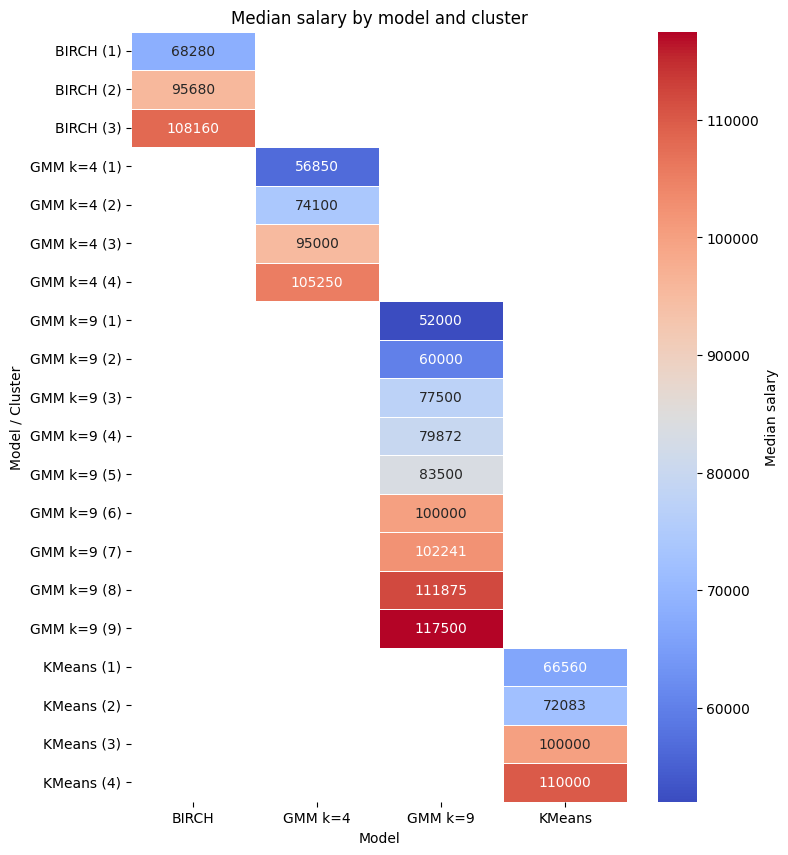

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

salary_heatmap = salary_median_table.copy()

salary_heatmap = (
    salary_heatmap
    .sort_values(
        ["model", "median"],
        ascending=[True, True]
    )
)

salary_heatmap["model_cluster"] = (
    salary_heatmap["model"]
    + " ("
    + salary_heatmap.groupby("model").cumcount().add(1).astype(str)
    + ")"
)

heatmap_data = salary_heatmap.pivot(
    index="model_cluster",
    columns="model",
    values="median"
)

plt.figure(figsize=(8, 10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"label": "Median salary"}
)

plt.title("Median salary by model and cluster")
plt.xlabel("Model")
plt.ylabel("Model / Cluster")

plt.show()

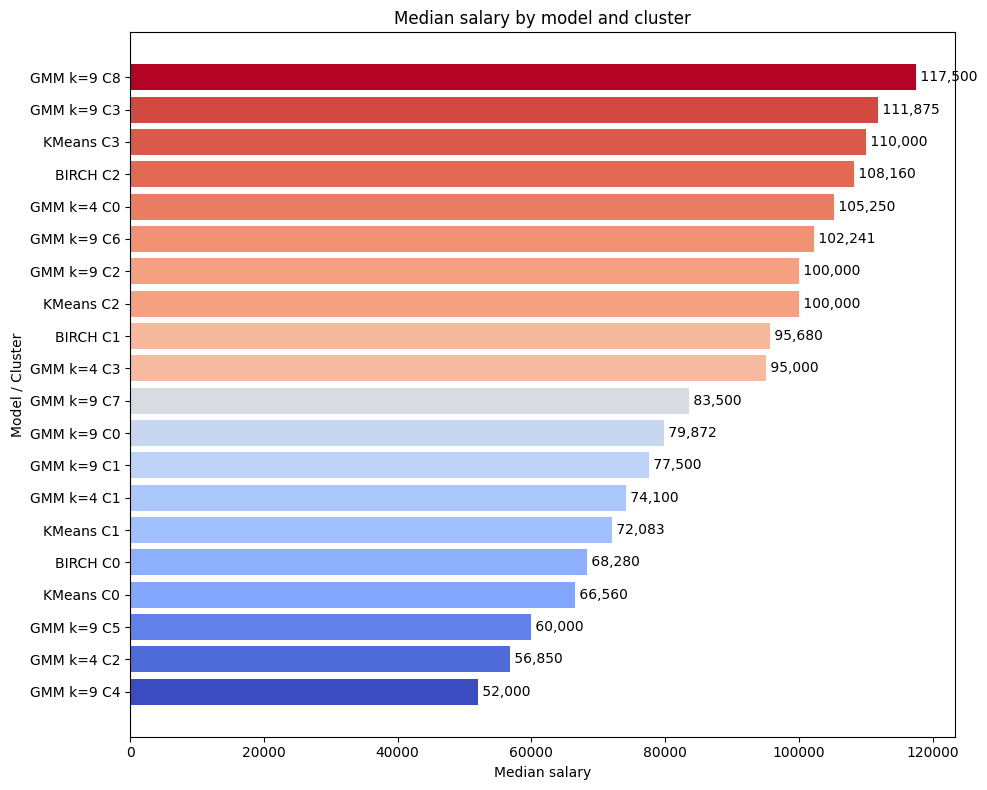

In [54]:
salary_plot = salary_median_table.sort_values("median").copy()

plt.figure(figsize=(10, 8))

bars = plt.barh(
    salary_plot["model_cluster"],
    salary_plot["median"],
    color=plt.cm.coolwarm(
        (salary_plot["median"] - salary_plot["median"].min()) /
        (salary_plot["median"].max() - salary_plot["median"].min())
    )
)

plt.xlabel("Median salary")
plt.ylabel("Model / Cluster")
plt.title("Median salary by model and cluster")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {width:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

Moze se primetiti da svi analizirani modeli formiraju klastere sa znacajno razlicitim nivoima plata. Razlike izmedju najmanje i najvise placenih klastera prelaze 50.000 dolara godisnje kod pojedinih modela, iako informacije o zaradi nisu koriscene tokom procesa klasterovanja.

Posebno se izdvajaju K-Means i BIRCH modeli, kod kojih se mogu uociti jasno definisani nivoi zarada od niskih ka visokim. GMM sa devet klastera ostvaruje najvecu granularnost i identifikuje vise razlicitih platnih segmenata, ukljucujuci i veoma visoko placene grupe sa medianom platom iznad 110.000 dolara.

Ovi rezultati predstavljaju snaznu potvrdu da dobijeni klasteri nisu formirani slucajno, vec da uspevaju da izdvoje segmente trzista rada koji se medjusobno razlikuju po ekonomskoj vrednosti radnih pozicija.

### Zasto su se klasteri razdvojili po plati iako plata nije koriscena?

Jedan od najzanimljivijih rezultata analize jeste cinjenica da su gotovo svi modeli uspeli da formiraju klastere sa znacajno razlicitim nivoima plata, iako atribut normalized_salary nije bio ukljucen u proces klasterovanja.

Ovakav rezultat ukazuje da su drugi atributi sadrzani u skupu podataka nosili informacije koje su indirektno povezane sa visinom zarade. Pre svega, nazivi poslova, trazene vestine, nivo iskustva, velicina kompanije i industrija predstavljaju karakteristike koje su u realnom svetu usko povezane sa nivoom plate.

Na primer, tehnicke pozicije poput Software Engineer, Data Engineer i Data Analyst najcesce zahtevaju specijalizovana znanja i iskustvo, zbog cega su u proseku bolje placene od poslova iz oblasti korisnicke podrske, administracije ili maloprodaje. Slicno tome, pozicije viseg nivoa iskustva i menadzerske funkcije uglavnom ostvaruju vece zarade od pocetnickih pozicija.

Tokom procesa klasterovanja algoritmi nisu imali direktan pristup informacijama o plati, ali su na osnovu slicnosti ostalih atributa uspeli da izdvoje grupe oglasa koje prirodno odgovaraju razlicitim segmentima trzista rada. Posmatrano iz ugla masinskog ucenja, plata predstavlja posledicu kombinacije vise karakteristika oglasa, a upravo su te karakteristike koriscene za formiranje klastera.

Zbog toga se moze zakljuciti da dobijeni klasteri ne predstavljaju samo statisticke grupe slicnih oglasa, vec segmente trzista rada koji se razlikuju i po svojoj ekonomskoj vrednosti.

## Kratka analiza Agglomerative i Spectral Clustering modela

Pored detaljno analiziranih modela K-Means, GMM i BIRCH, izvrsena je i dodatna analiza Agglomerative i Spectral Clustering algoritama. Zbog njihove vece racunske slozenosti, evaluacija ovih metoda sprovedena je nad slucajnim uzorcima podataka od 10.000 (Agglomerative) i 5.000 instanci (Spectral).

Cilj ove analize nije bio izbor konacnog modela za segmentaciju, vec provera da li alternativni pristupi klasterovanju dovode do slicne strukture podataka i da li formirani klasteri imaju smisleno poslovno tumacenje. U nastavku su prikazane osnovne karakteristike dobijenih klastera, ukljucujuci raspodelu instanci, plate, industrije i ostale relevantne atribute.

Rezultati ovih modela posmatraju se kao dopunska validacija prethodno izvedenih zakljucaka, pri cemu treba imati u vidu da zbog rada nad manjim uzorcima nisu potpuno direktno uporedivi sa modelima treniranim nad kompletnim skupom podataka.

In [92]:
import numpy as np

spectral_idx = np.load("../models/spectral_sample_idx.npy")

In [99]:
spectral_sample = master_raw.iloc[spectral_idx].copy()
spectral_sample["cluster"] = spectral_labels

In [95]:
sample_idx = np.load("../models/sample_idx.npy")

In [100]:
agg_sample = master_raw.iloc[sample_idx].copy()
agg_sample["cluster"] = agg_labels

### 1. Agglomerative Clustering model

In [101]:
agg_summary = pd.DataFrame({
    "Cluster %": (
        pd.Series(agg_labels)
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    ),
    "Median salary": (
        agg_sample
        .groupby("cluster")["normalized_salary"]
        .median()
        .round(0)
    )
})

agg_summary

,Cluster %,Median salary
0,35.95,78000.0
1,8.84,85935.0
2,18.76,80000.0
3,16.73,58140.0
4,12.63,81500.0
5,7.09,50003.0


In [104]:
top_titles_agg = pd.DataFrame()

for c in sorted(np.unique(agg_labels)):
    
    top_titles_agg[f"Cluster {c}"] = (
        agg_sample
        .loc[agg_sample["cluster"] == c, "title"]
        .value_counts()
        .head(5)
        .index
    )

top_titles_agg

,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5
0,Sales Manager,Receptionist,Receptionist,Cook,Salesperson,Rental Linen & Uniform Sales
1,Service Technician,LICENSED PRACTICAL NURSE (LPN) - THE FOLEY CEN...,Hair Stylist,Office Accountant/Manager,Administrative Assistant,Powerpoint/Presentation Specialist
2,Receptionist,"Senior Partner Solutions Architect, Financial ...",Union Delivery Truck Driver - CDL Class A,HQ District Sales Manager,Receptionist,Staff Nurse (RN) - Per Diem
3,Nurse Practitioner,Sales Specialist,Rehab Therapy Manager,Technical Writer,RN Wound Specialist - Home Health,Host Associate-Food Service
4,"Physical Therapist (PT) - $5,000.00 Sign On Bo...",Asset Visibility Logistic Analyst (CIPBO),Driver - CDL (B),Database Support Analyst,Senior Billing Representative,RN Home Health


<Figure size 700x400 with 0 Axes>

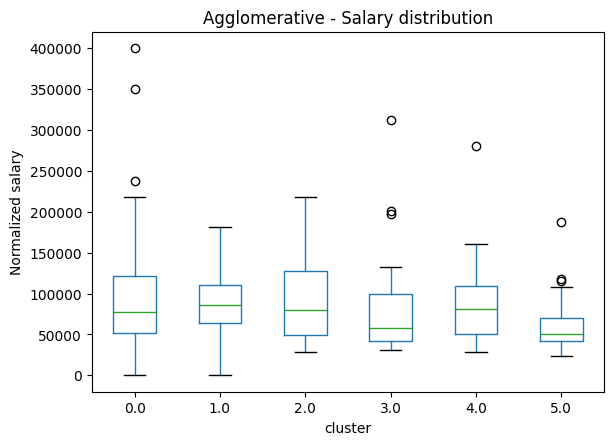

In [105]:
plt.figure(figsize=(7,4))

agg_sample.boxplot(
    column="normalized_salary",
    by="cluster",
    grid=False
)

plt.suptitle("")
plt.title("Agglomerative - Salary distribution")
plt.ylabel("Normalized salary")
plt.show()

### Zakljucak

Agglomerative Clustering formirao je sest relativno uravnotezenih klastera sa vrednoscu silhouette score od 0.286. Analiza plata pokazuje da postoje uocljive razlike izmedju pojedinih klastera, pri cemu se izdvajaju bolje i losije placene grupe poslova. Medjutim, analiza dominantnih naziva pozicija pokazuje da su klasteri prilicno heterogeni i da okupljaju vise razlicitih profesija. Zbog toga, iako model uspeva da identifikuje odredjene strukturne razlike u podacima, dobijeni klasteri su manje interpretabilni u odnosu na rezultate ostvarene K-Means algoritmom.

### 2. Spectral Clustering model

In [107]:
spectral_summary = pd.DataFrame({
    "Cluster %": (
        pd.Series(spectral_labels)
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    ),
    "Median salary": (
        spectral_sample
        .groupby("cluster")["normalized_salary"]
        .median()
        .round(0)
    )
})

spectral_summary

,Cluster %,Median salary
0,51.4,62500.0
1,48.6,81435.0


In [108]:
top_titles_spectral = pd.DataFrame()

for c in sorted(np.unique(spectral_labels)):
    
    top_titles_spectral[f"Cluster {c}"] = (
        spectral_sample
        .loc[spectral_sample["cluster"] == c, "title"]
        .value_counts()
        .head(5)
        .index
    )

top_titles_spectral

,Cluster 0,Cluster 1
0,HQ District Sales Manager,Sales Manager
1,Property Maintenance | Mental Health,Account Executive
2,Rehab Therapy Manager,Salesperson
3,Driver - CDL (B),Store Manager
4,Business Analyst 4,Service Manager


<Figure size 700x400 with 0 Axes>

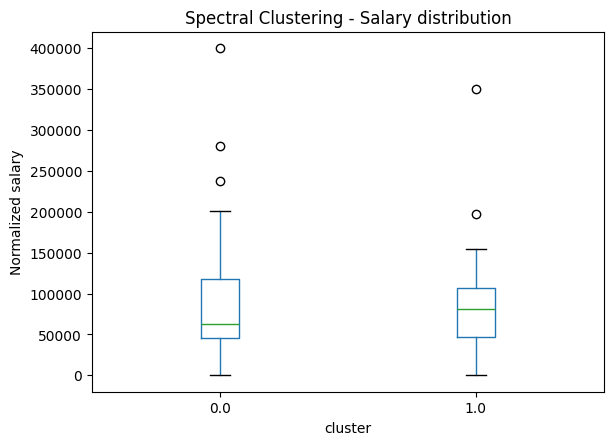

In [110]:
plt.figure(figsize=(7,4))

spectral_sample.boxplot(
    column="normalized_salary",
    by="cluster",
    grid=False
)

plt.suptitle("")
plt.title("Spectral Clustering - Salary distribution")
plt.ylabel("Normalized salary")
plt.show()

### Zakljucak

Spectral Clustering ostvario je silhouette score od 0.315 i formirao dva gotovo podjednako velika klastera. Analiza plata pokazuje uocljivu razliku izmedju klastera, pri cemu jedan klaster obuhvata oglase sa znacajno visim medijalnim platama. Sa druge strane, analiza dominantnih naziva pozicija ne ukazuje na jasno izdvojene profesionalne grupe, vec na prisustvo razlicitih tipova poslova unutar oba klastera. Zbog toga se moze zakljuciti da Spectral Clustering identifikuje odredjene strukturne razlike u podacima, ali rezultati ostaju manje interpretabilni u odnosu na K-Means model.

# Izbor najboljeg modela

Do ovog trenutka analizirani su rezultati vise algoritama klasterovanja kroz kombinaciju internih metrika kvaliteta, raspodele instanci po klasterima i karakteristika koje nisu koriscene tokom procesa treniranja.

Poredjenje silhouette score vrednosti pokazalo je da je K-Means ostvario najbolji rezultat medju analiziranim modelima. Medjutim, izbor najboljeg modela nije zasnovan iskljucivo na ovoj metrici. Posebna paznja posvecena je i interpretabilnosti dobijenih klastera, njihovoj uravnotezenosti i sposobnosti da izdvoje segmente koji imaju poslovno smisleno tumacenje.

Analiza nivoa iskustva pokazala je da K-Means formira klastere sa jasnim razlikama u profesionalnom profilu kandidata, dok je analiza plata dodatno potvrdila kvalitet dobijene segmentacije. Iako atribut normalized_salary nije bio ukljucen tokom klasterovanja, K-Means je uspeo da izdvoji klastere sa znacajno razlicitim nivoima zarada, sto ukazuje da model identifikuje stvarne obrasce prisutne na trzistu rada.

Dodatnu prednost predstavlja i relativno jednostavna interpretacija klastera. Analiza najcescih naziva poslova pokazala je da se tehnicke, menadzerske, administrativne i korisnicke pozicije grupisu u odvojene segmente sa jasnim identitetom.

Na osnovu svih sprovedenih analiza, K-Means je izabran kao model koji ce biti koriscen za detaljnu interpretaciju i profilisanje klastera u nastavku rada.

# Detaljna interpretacija K-Means klastera

Nakon izbora K-Means algoritma kao najpogodnijeg modela, u nastavku se sprovodi detaljna analiza njegovih klastera. Cilj ove faze nije vise poredjenje algoritama, vec razumevanje karakteristika koje definisu svaki od identifikovanih segmenata trzista rada.

Za svaki klaster analiziraju se dominantne vestine, velicina kompanija, benefiti i druge karakteristike oglasa kako bi se dobila sto jasnija slika o tipovima poslova koji pripadaju pojedinim segmentima.

Na osnovu ovih analiza moguce je formirati profile klastera i identifikovati njihove kljucne osobine, sto predstavlja krajnji cilj procesa klasterovanja.

## Analiza velicine kompanije

company_size_group,Large,Medium,Small
cluster,,,
0,82.38,17.61,0.02
1,2.51,55.23,42.25
2,45.74,43.82,10.44
3,11.71,57.58,30.71


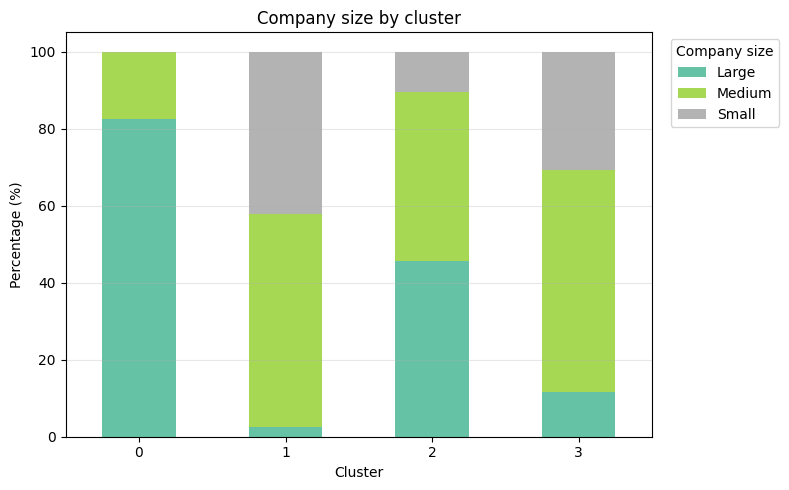

In [60]:
master["cluster"] = kmeans_labels
size_map = {
    1: "Small",
    2: "Small",
    3: "Medium",
    4: "Medium",
    5: "Medium",
    6: "Large",
    7: "Large"
}

master["company_size_group"] = master["company_size"].map(size_map)

company_size_profile = (
    pd.crosstab(
        master["cluster"],
        master["company_size_group"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

display(company_size_profile)

company_size_profile.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    colormap="Set2"
)

plt.title("Company size by cluster")
plt.xlabel("Cluster")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(
    title="Company size",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Analiza velicine kompanija pokazuje da se klasteri razlikuju i po organizacionom okruzenju u kojem se poslovi najcesce pojavljuju. Iako velicina kompanije nije bila direktno povezana sa procesom klasterovanja, mogu se uociti jasne razlike u raspodeli oglasa izmedju pojedinih klastera.

Klaster 0 dominantno sadrzi oglase velikih kompanija, dok su klasteri 1 i 3 zastupljeniji u manjim i srednje velikim organizacijama. Klaster 2 pokazuje najuravnotezeniju raspodelu izmedju srednjih i velikih kompanija.

Rezultati ukazuju da klasteri ne odrazavaju samo razlike u tipovima poslova i nivoima plata, vec i razlike u karakteristikama poslodavaca. Ovo dodatno potvrdjuje da su identifikovani segmenti povezani sa stvarnim obrascima prisutnim na trzistu rada, a ne iskljucivo sa pojedinacnim atributima oglasa.

## Analiza industrija

In [61]:
object_cols = master.select_dtypes(include="object").columns.tolist()
numeric_cols = master.select_dtypes(exclude="object").columns.tolist()

object_cols

['title',
 'formatted_work_type',
 'application_type',
 'formatted_experience_level',
 'country',
 'company_size_group']

In [63]:
binary_cols = []

for col in numeric_cols:
    vals = master[col].dropna().unique()
    if len(vals) <= 2 and set(vals).issubset({0, 1, 0.0, 1.0}):
        binary_cols.append(col)

Poslednjih 75 binarnih atributa predstavljaju one-hot kodirane industrije.

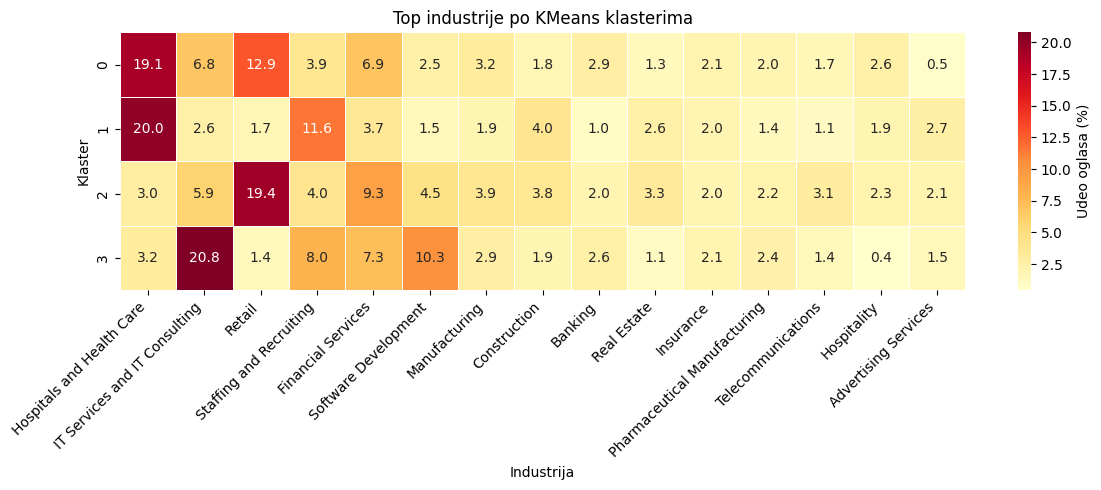

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

master["cluster"] = kmeans_labels
industry_cols = binary_cols[-75:]
industry_cols = [
    col
    for col in industry_cols
    if col != "cluster"
]

industry_profile = (
    master
    .groupby("cluster")[industry_cols]
    .mean()
    .mul(100)
    .round(2)
)
top_industries = (
    industry_profile
    .mean(axis=0)
    .sort_values(ascending=False)
    .head(15)
    .index
)

industry_heatmap = industry_profile[top_industries]

plt.figure(figsize=(12, 5))

sns.heatmap(
    industry_heatmap,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Udeo oglasa (%)"}
)

plt.title("Top industrije po KMeans klasterima")
plt.xlabel("Industrija")
plt.ylabel("Klaster")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Analiza industrija dodatno potvrdjuje da dobijeni klasteri predstavljaju smislene segmente trzista rada. Za razliku od prethodnih analiza koje su se oslanjale na nazive poslova ili nivo iskustva, ovde se posmatra poslovni sektor u kome se oglasi najcesce pojavljuju.

Rezultati pokazuju da svaki klaster ima karakteristicne industrije koje se izdvajaju u odnosu na ostale. Posebno se istice klaster 3, kod koga dominiraju IT Services and IT Consulting i Software Development, sto je u skladu sa velikim brojem tehnickih i analitickih pozicija identifikovanih tokom prethodnih analiza. Klaster 2 karakterise visoka zastupljenost Retail industrije, dok klasteri 0 i 1 imaju znacajno veci udeo oglasa iz oblasti Hospitals and Health Care.

Ovakva raspodela predstavlja dodatnu potvrdu kvaliteta klasterovanja, jer pokazuje da model nije grupisao oglase samo prema pojedinacnim atributima, vec je uspeo da izdvoji segmente koji odgovaraju razlicitim industrijskim sektorima. Dobijeni klasteri stoga imaju jasno poslovno tumacenje i mogu se posmatrati kao razliciti delovi trzista rada.

## Analiza vestina

In [88]:
industry_cols = [c for c in master.columns[-75:] if c != "cluster"]

non_industry_cols = [
    c for c in master.columns
    if c not in industry_cols and c != "cluster"
]
binary_cols = []

for col in non_industry_cols:
    if col in ["title", "formatted_work_type", "application_type", 
               "formatted_experience_level", "country"]:
        continue

    vals = master[col].dropna().unique()
    if len(vals) <= 2 and set(vals).issubset({0, 1, 0.0, 1.0}):
        binary_cols.append(col)

In [ ]:
# Prvih 35 binarnih atributa odnosi se na prisustvo pojedinačnih vestina
skill_cols = binary_cols[:35]

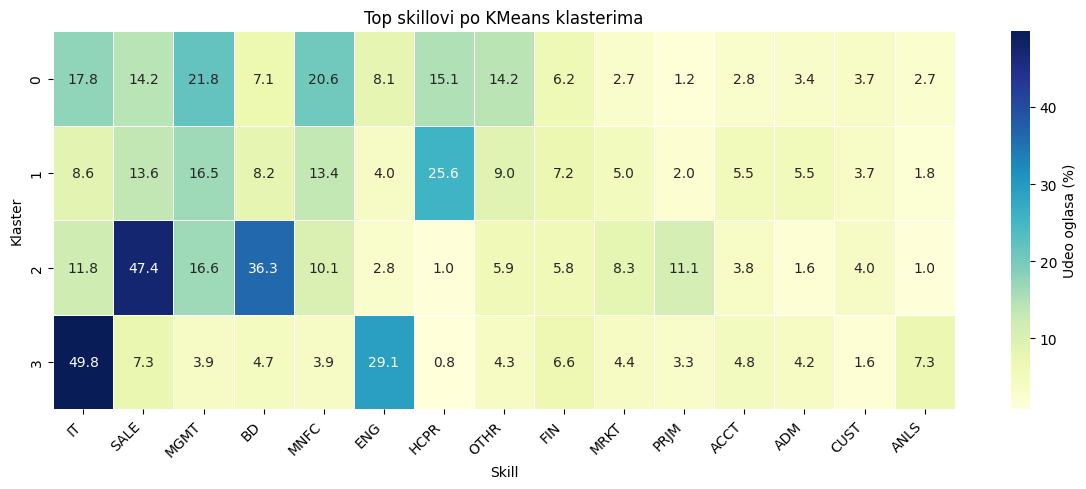

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

skill_profile = (
    master
    .groupby("cluster")[skill_cols]
    .mean()
    .mul(100)
    .round(2)
)

top_skills = (
    skill_profile
    .mean(axis=0)
    .sort_values(ascending=False)
    .head(15)
    .index
)

skill_heatmap = skill_profile[top_skills]

plt.figure(figsize=(12, 5))

sns.heatmap(
    skill_heatmap,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Udeo oglasa (%)"}
)

plt.title("Top skillovi po KMeans klasterima")
plt.xlabel("Skill")
plt.ylabel("Klaster")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

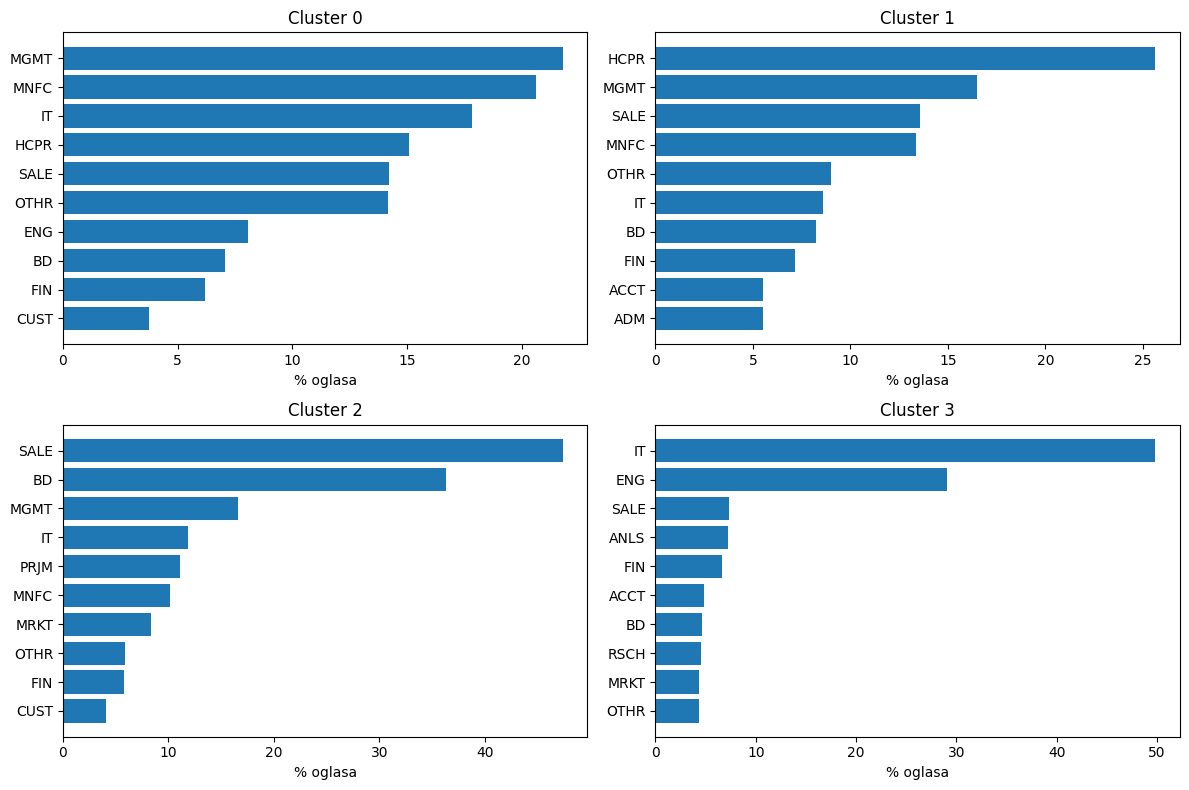

In [91]:
import matplotlib.pyplot as plt

skill_profile = (
    master
    .groupby("cluster")[skill_cols]
    .mean()
    .mul(100)
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for cluster, ax in zip(skill_profile.index, axes):

    top = (
        skill_profile.loc[cluster]
        .sort_values(ascending=True)
        .tail(10)
    )

    ax.barh(top.index, top.values)

    ax.set_title(f"Cluster {cluster}")
    ax.set_xlabel("% oglasa")

plt.tight_layout()
plt.show()

Analiza vestina predstavlja jednu od najinformativnijih metoda za interpretaciju dobijenih klastera, jer direktno opisuje znanja i kompetencije koje se zahtevaju za pojedine pozicije.

Rezultati pokazuju veoma jasnu specijalizaciju pojedinih klastera. Klaster 3 dominantno okuplja tehnicke i inzenjerske pozicije, sa izrazito visokim udelom IT i Engineering vestina. Ovakav profil odgovara pozicijama kao sto su Software Engineer, Data Engineer i Data Analyst, koje su identifikovane tokom analize naziva poslova.

Klaster 2 predstavlja poslovni i prodajni segment trzista rada. U ovom klasteru dominiraju Sales i Business Development vestine, sto je u skladu sa velikim brojem menadzerskih i prodajnih pozicija koje su prethodno identifikovane.

Klaster 1 pokazuje izrazenu zastupljenost Healthcare Provider vestina, uz prisustvo administrativnih i menadzerskih kompetencija. Ovakav profil odgovara zdravstvenim i profesionalnim uslugama koje su bile vidljive i tokom analize industrija.

Klaster 0 predstavlja najheterogeniji segment, sa kombinacijom menadzerskih, proizvodnih, tehnickih i zdravstvenih vestina. Za razliku od ostalih klastera koji pokazuju jasnu specijalizaciju, ovaj klaster okuplja siri spektar operativnih i administrativnih poslova.

Dobijeni rezultati predstavljaju dodatnu potvrdu kvaliteta klasterovanja. Iako informacije o platama nisu koriscene tokom treniranja modela, klasteri koji okupljaju tehnicke i specijalizovane vestine istovremeno ostvaruju i vise nivoe zarada, dok klasteri sa operativnim i administrativnim profilom imaju nize mediane plata. Time se potvrdjuje da identifikovani segmenti odgovaraju stvarnim grupama poslova prisutnim na trzistu rada.

# Zakljucak

Na osnovu sprovedenih analiza moze se zakljuciti da je K-Means algoritam uspeo da identifikuje cetiri jasno definisana segmenta trzista rada. Iako ostvareni silhouette score od 0.336 ne ukazuje na potpuno odvojene klastere, detaljna interpretacija pokazuje da dobijene grupe imaju smisleno poslovno tumacenje i odrazavaju stvarne razlike izmedju tipova poslova prisutnih u skupu podataka.

### Klaster 0 - Operativni poslovi velikih kompanija

Klaster 0 karakterisu pozicije iz oblasti korisnicke podrske, maloprodaje, logistike i administrativnih poslova. Dominiraju nazivi poput Customer Service Representative, Receptionist i Retail Sales Associate. Poslovi iz ovog segmenta najcesce dolaze iz velikih kompanija, dok su mediane plata medju najnizima u skupu podataka. Profil vestina pokazuje kombinaciju menadzerskih, proizvodnih i tehnickih kompetencija bez izrazene specijalizacije, zbog cega se ovaj klaster moze posmatrati kao grupa operativnih i podrzavajucih poslovnih funkcija.

### Klaster 1 - Zdravstvene i profesionalne usluge

Klaster 1 okuplja zdravstvene i profesionalne pozicije, ukljucujuci Registered Nurse, Physical Therapist i Licensed Therapist. Industrijska analiza pokazuje veliku zastupljenost sektora Hospitals and Health Care, dok profil vestina karakterise izrazeno prisustvo Healthcare Provider kompetencija. Plate su vise nego u operativnom segmentu, ali i dalje nize od tehnickih i menadzerskih klastera. Ovaj segment predstavlja specijalizovane profesionalne usluge sa naglaskom na zdravstveni sektor.

### Klaster 2 - Menadzment, prodaja i poslovni razvoj

Klaster 2 jasno predstavlja poslovni i prodajni segment trzista rada. Dominiraju pozicije kao sto su Sales Manager, Project Manager, Account Manager i Business Development Manager. Vestine Sales i Business Development znacajno se izdvajaju u odnosu na ostale klastere, dok industrijska analiza pokazuje veliku zastupljenost Retail sektora. Ovaj klaster ostvaruje znacajno vise mediane plata i predstavlja grupu poslova povezanih sa upravljanjem, prodajom i razvojem poslovanja.

### Klaster 3 - Tehnicki i analiticki poslovi

Klaster 3 predstavlja najjasnije definisan segment. Dominiraju pozicije Software Engineer, Senior Software Engineer, Data Engineer i Data Analyst. Industrije IT Services and IT Consulting i Software Development imaju najvecu zastupljenost upravo u ovom klasteru, dok profil vestina pokazuje izrazitu dominaciju IT i Engineering kompetencija. Ovaj klaster ostvaruje i najvise mediane plate u okviru K-Means modela, sto dodatno potvrduje da predstavlja segment visokokvalifikovanih tehnickih i analitickih zanimanja.

Posmatrajuci sve rezultate zajedno, moze se zakljuciti da klasteri nisu formirani slucajno. Iako plata nije bila ukljucena u proces klasterovanja, model je uspeo da izdvoji segmente sa znacajno razlicitim nivoima zarada. Istovremeno, razlike u vestinama, industrijama, velicini kompanija i nazivima poslova dodatno potvrdjuju da identifikovani klasteri odgovaraju stvarnim grupama poslova prisutnim na trzistu rada.

Zbog toga se moze zakljuciti da K-Means model, uprkos umerenoj vrednosti silhouette score metrike od 0.336, uspeva da otkrije smislenu strukturu podataka i izdvoji poslovno interpretabilne segmente trzista rada.